## Preamble

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from math import pi

from cpymad.madx import Madx

# Comment out the following lines if plotting cells give an error
import sys
import os
parent_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.append(parent_dir)
from plot_settings import setPlotSettings
setPlotSettings(font=True)

## Case 1 -- quad error off

In [56]:
madx = Madx(stdout=False)
madx.input(f'''
    beam, particle=proton, energy=275.0;
    // Geometry
    L_drift     = 2.116775;
    L_dipole    = 9.45;
    theta       = 0.038924;
    L_half_quad = 0.555;
    
    // Strengths
    kf = 0.08537;
    kd = kf;
    
    k_error_6 =  0.0;     // error initially OFF !!
    k_error_7 =  0.0;     // error initially OFF  !!
    
    // Drifts
    D: DRIFT,  L = L_drift;
    
    // Dipoles
    DIP: SBEND, L = L_dipole, ANGLE = theta;
    
    // Quadrupoles -- half length
    QFH1:  QUADRUPOLE, L= L_half_quad, K1=  kf;
    QDH1:  QUADRUPOLE, L= L_half_quad, K1= -kd;
    QFH2:  QUADRUPOLE, L= L_half_quad, K1=  kf;
    QDH2:  QUADRUPOLE, L= L_half_quad, K1= -kd;
    QFH3:  QUADRUPOLE, L= L_half_quad, K1=  kf;
    QDH3:  QUADRUPOLE, L= L_half_quad, K1= -kd;
    QFH4:  QUADRUPOLE, L= L_half_quad, K1=  kf;
    QDH4:  QUADRUPOLE, L= L_half_quad, K1= -kd;
    QFH5:  QUADRUPOLE, L= L_half_quad, K1=  kf;
    QDH5:  QUADRUPOLE, L= L_half_quad, K1= -kd;
    QFH6:  QUADRUPOLE, L= L_half_quad, K1=  (kf + k_error_6);
    QDH6:  QUADRUPOLE, L= L_half_quad, K1= -kd;
    QFH7:  QUADRUPOLE, L= L_half_quad, K1=  (kf + k_error_7);
    QDH7:  QUADRUPOLE, L= L_half_quad, K1= -kd;
    QFH8:  QUADRUPOLE, L= L_half_quad, K1=  kf;
    QDH8:  QUADRUPOLE, L= L_half_quad, K1= -kd;
    QFH9:  QUADRUPOLE, L= L_half_quad, K1=  kf;
    QDH9:  QUADRUPOLE, L= L_half_quad, K1= -kd;
    QFH10: QUADRUPOLE, L= L_half_quad, K1=  kf;
    QDH10: QUADRUPOLE, L= L_half_quad, K1= -kd;
    
    // Beamlines
    FODODIP: LINE=(D, DIP, D);          // Interior of a half cell
    
    FODO1: LINE=(QFH1,  FODODIP, 2*QDH1,  FODODIP, QFH2);
    FODO2: LINE=(QFH2,  FODODIP, 2*QDH2,  FODODIP, QFH3);
    FODO3: LINE=(QFH3,  FODODIP, 2*QDH3,  FODODIP, QFH4);
    FODO4: LINE=(QFH4,  FODODIP, 2*QDH4,  FODODIP, QFH5);
    FODO5: LINE=(QFH5,  FODODIP, 2*QDH5,  FODODIP, QFH6);
    FODO6: LINE=(QFH6,  FODODIP, 2*QDH6,  FODODIP, QFH7);
    FODO7: LINE=(QFH7,  FODODIP, 2*QDH7,  FODODIP, QFH8);
    FODO8: LINE=(QFH8,  FODODIP, 2*QDH8,  FODODIP, QFH9);
    FODO9: LINE=(QFH9,  FODODIP, 2*QDH9,  FODODIP, QFH10);
    FODO10:LINE=(QFH10, FODODIP, 2*QDH10, FODODIP, QFH1);
    
    FODO_MANY: LINE=(FODO1, FODO2, FODO3, FODO4, FODO5, FODO6, FODO7, FODO8, FODO9, FODO10);
    
    use, sequence=fodo_many;
    // select,                     flag=twiss,column=name,s,betx,bety,alfx,alfy,dx,mux,muy; // see all magnets
       select, class = quadrupole, flag=twiss,column=name,s,betx,bety,alfx,alfy,dx,mux,muy; // see quads only
    set, format="-22s", "11.6f";
    
    twiss, save, file=quad_err.twi;
    ''')
twiss = madx.table.twiss

### Beta function

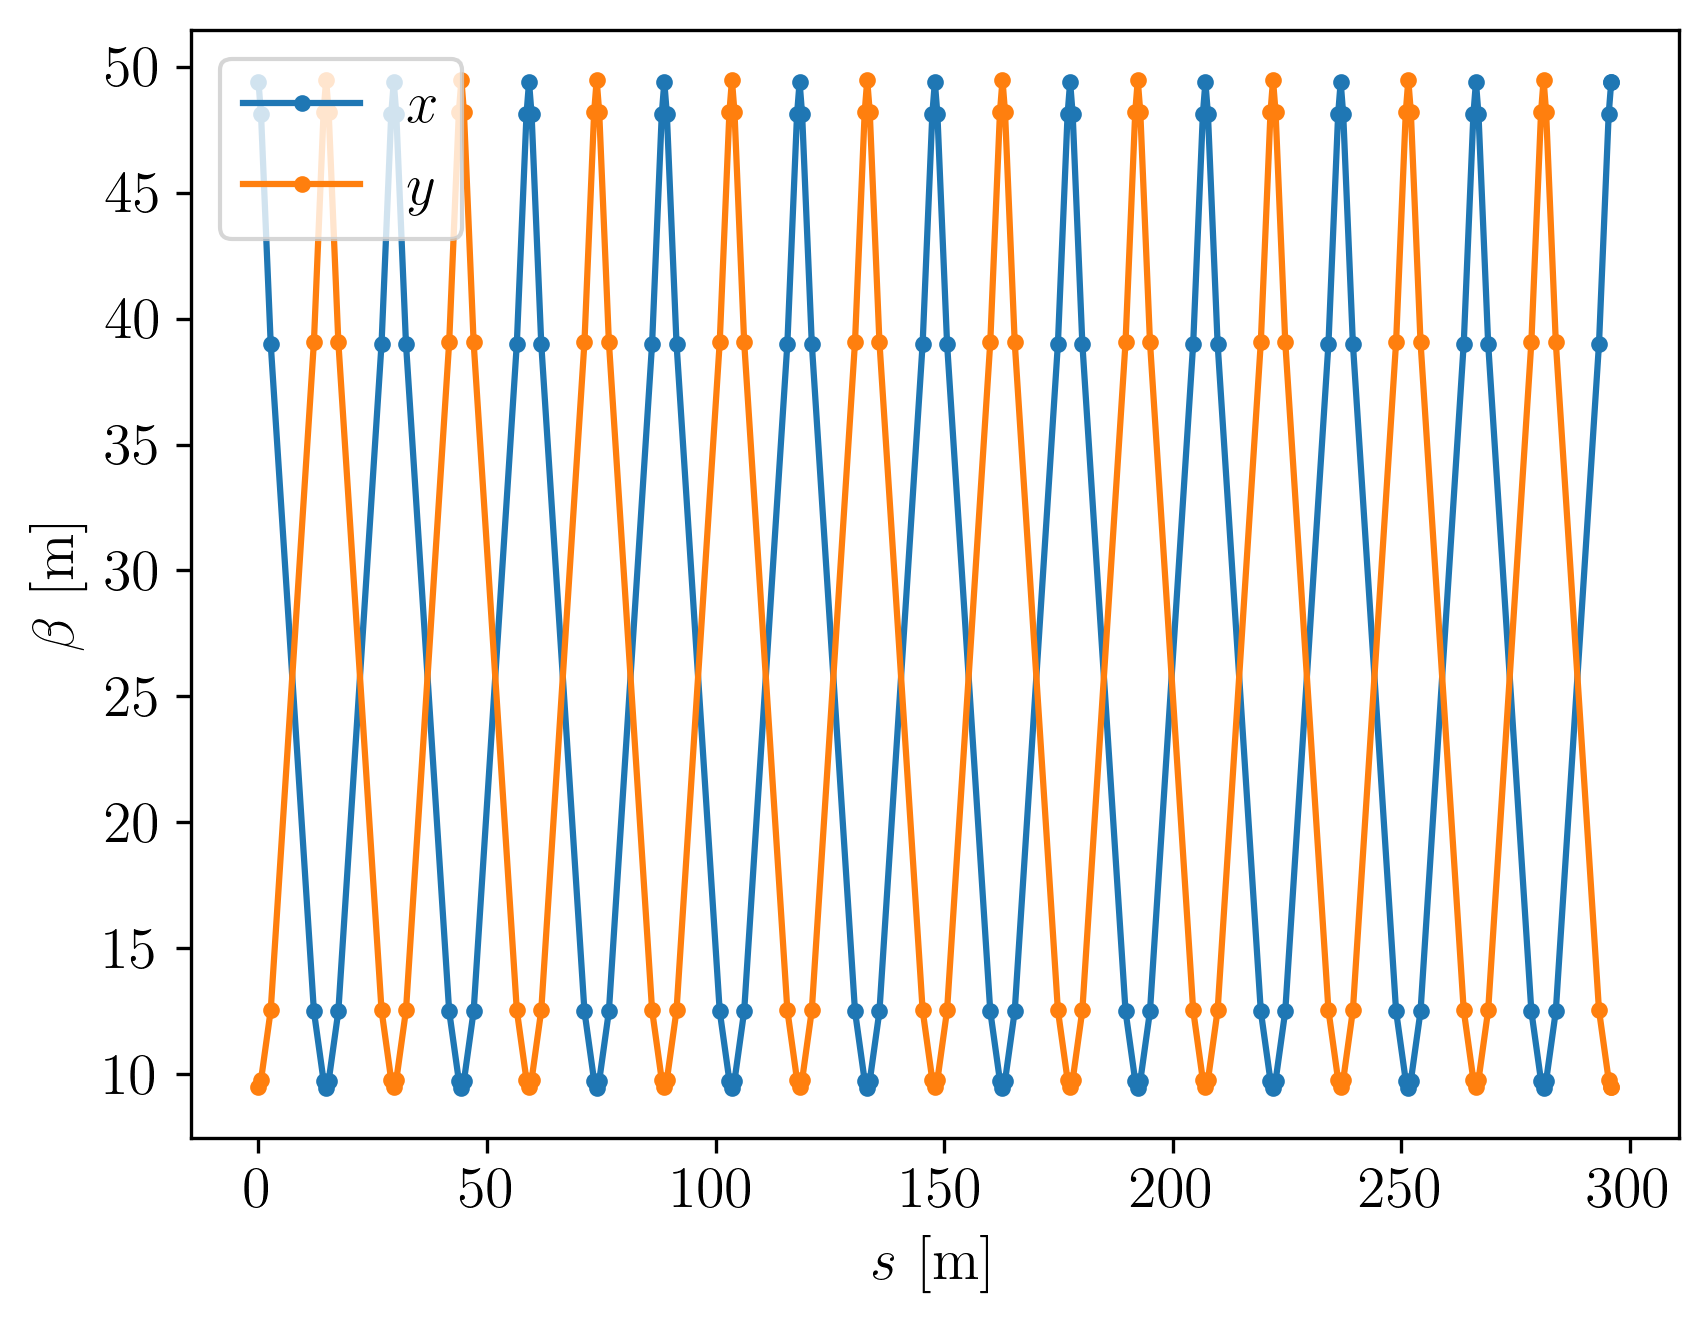

In [57]:
plt.plot(twiss.s,twiss.betx,'.-',label='$x$')
plt.plot(twiss.s,twiss.bety,'.-',label='$y$')
plt.ylabel(r'$\beta$ [m]')
plt.xlabel('$s$ [m]')
plt.legend(loc='upper left')
plt.show()

### Dispersion

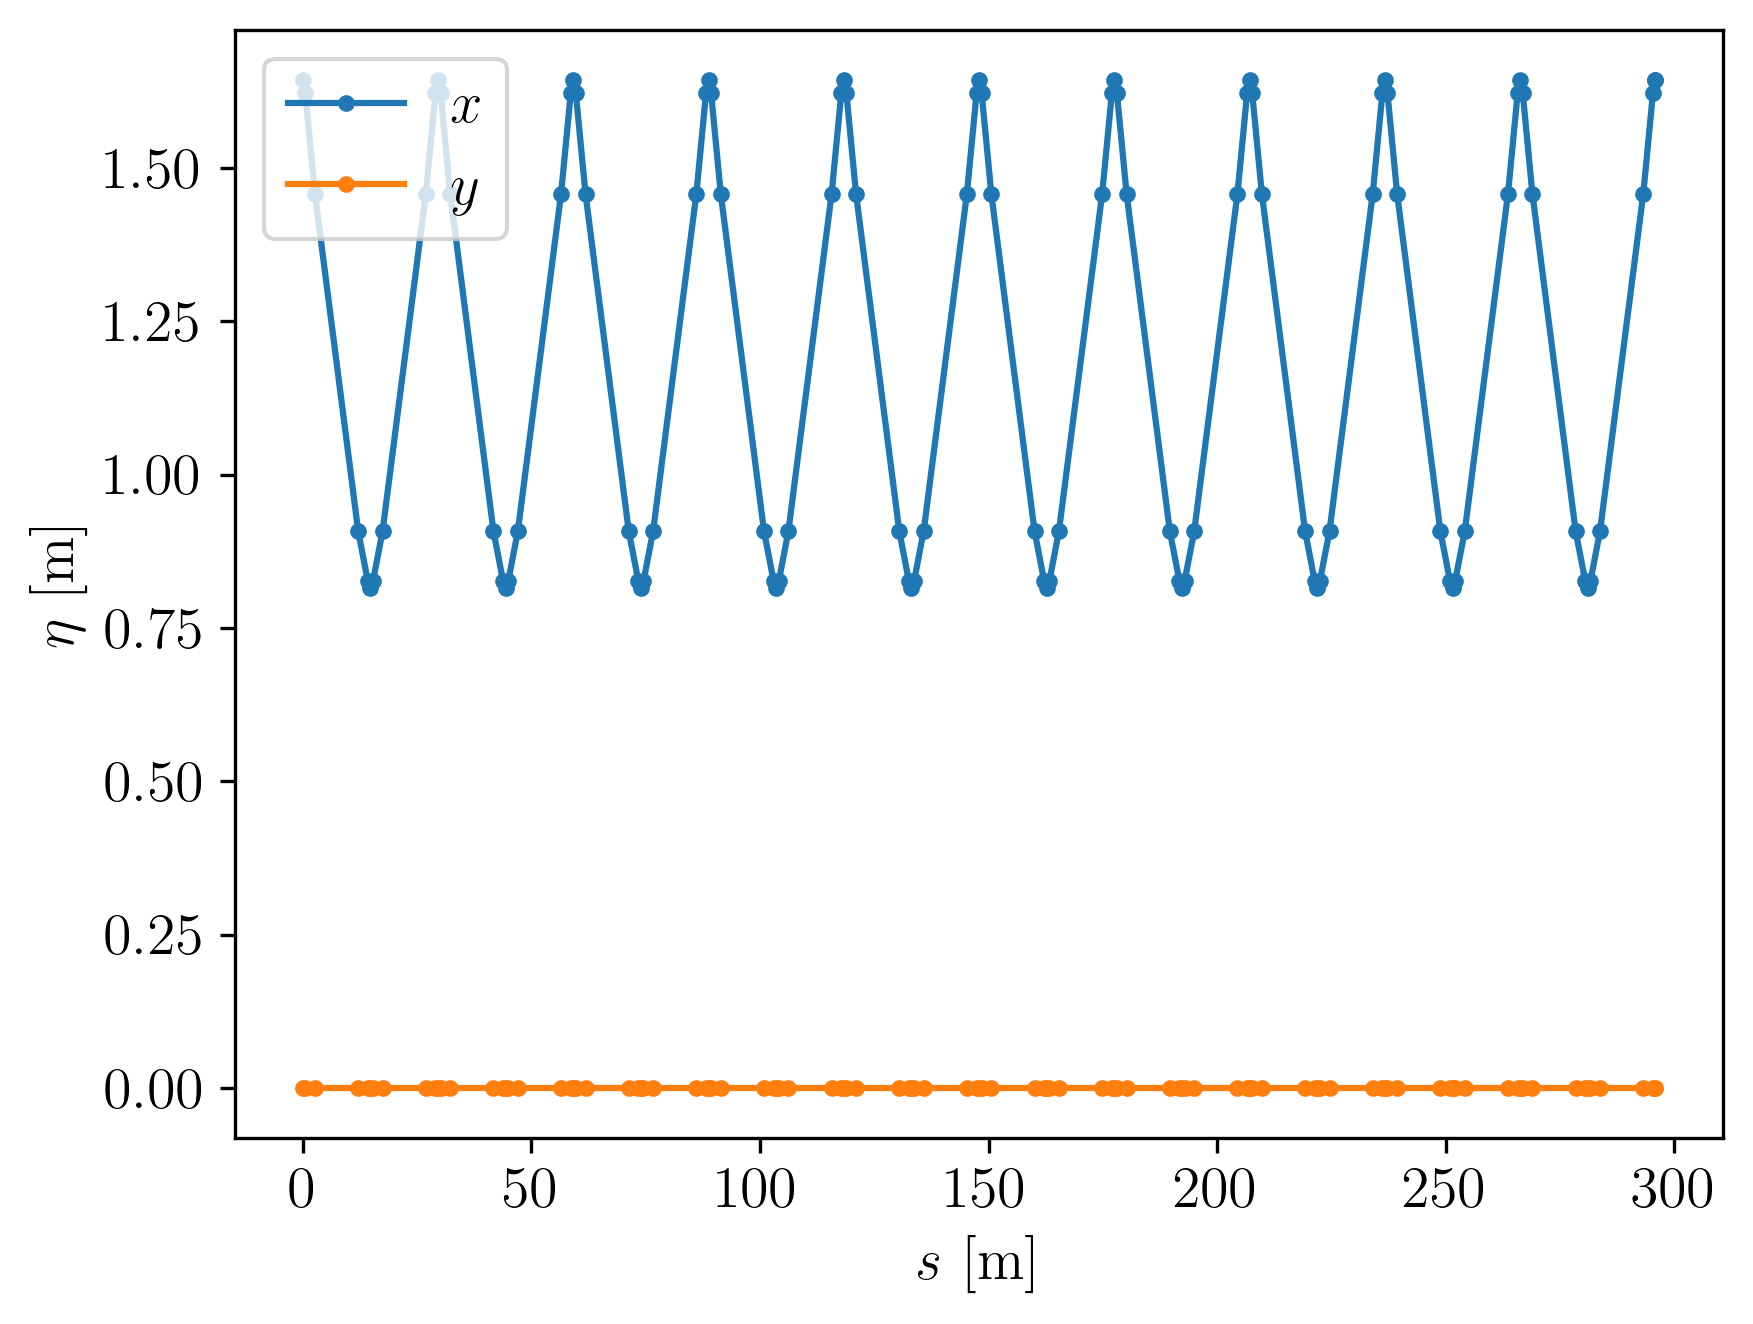

In [58]:
plt.plot(twiss.s,twiss.dx,'.-',label='$x$')
plt.plot(twiss.s,twiss.dy,'.-',label='$y$')
plt.ylabel(r'$\eta$ [m]')
plt.xlabel('$s$ [m]')
plt.legend(loc='upper left')
plt.show()

### Phase advance

Globally:

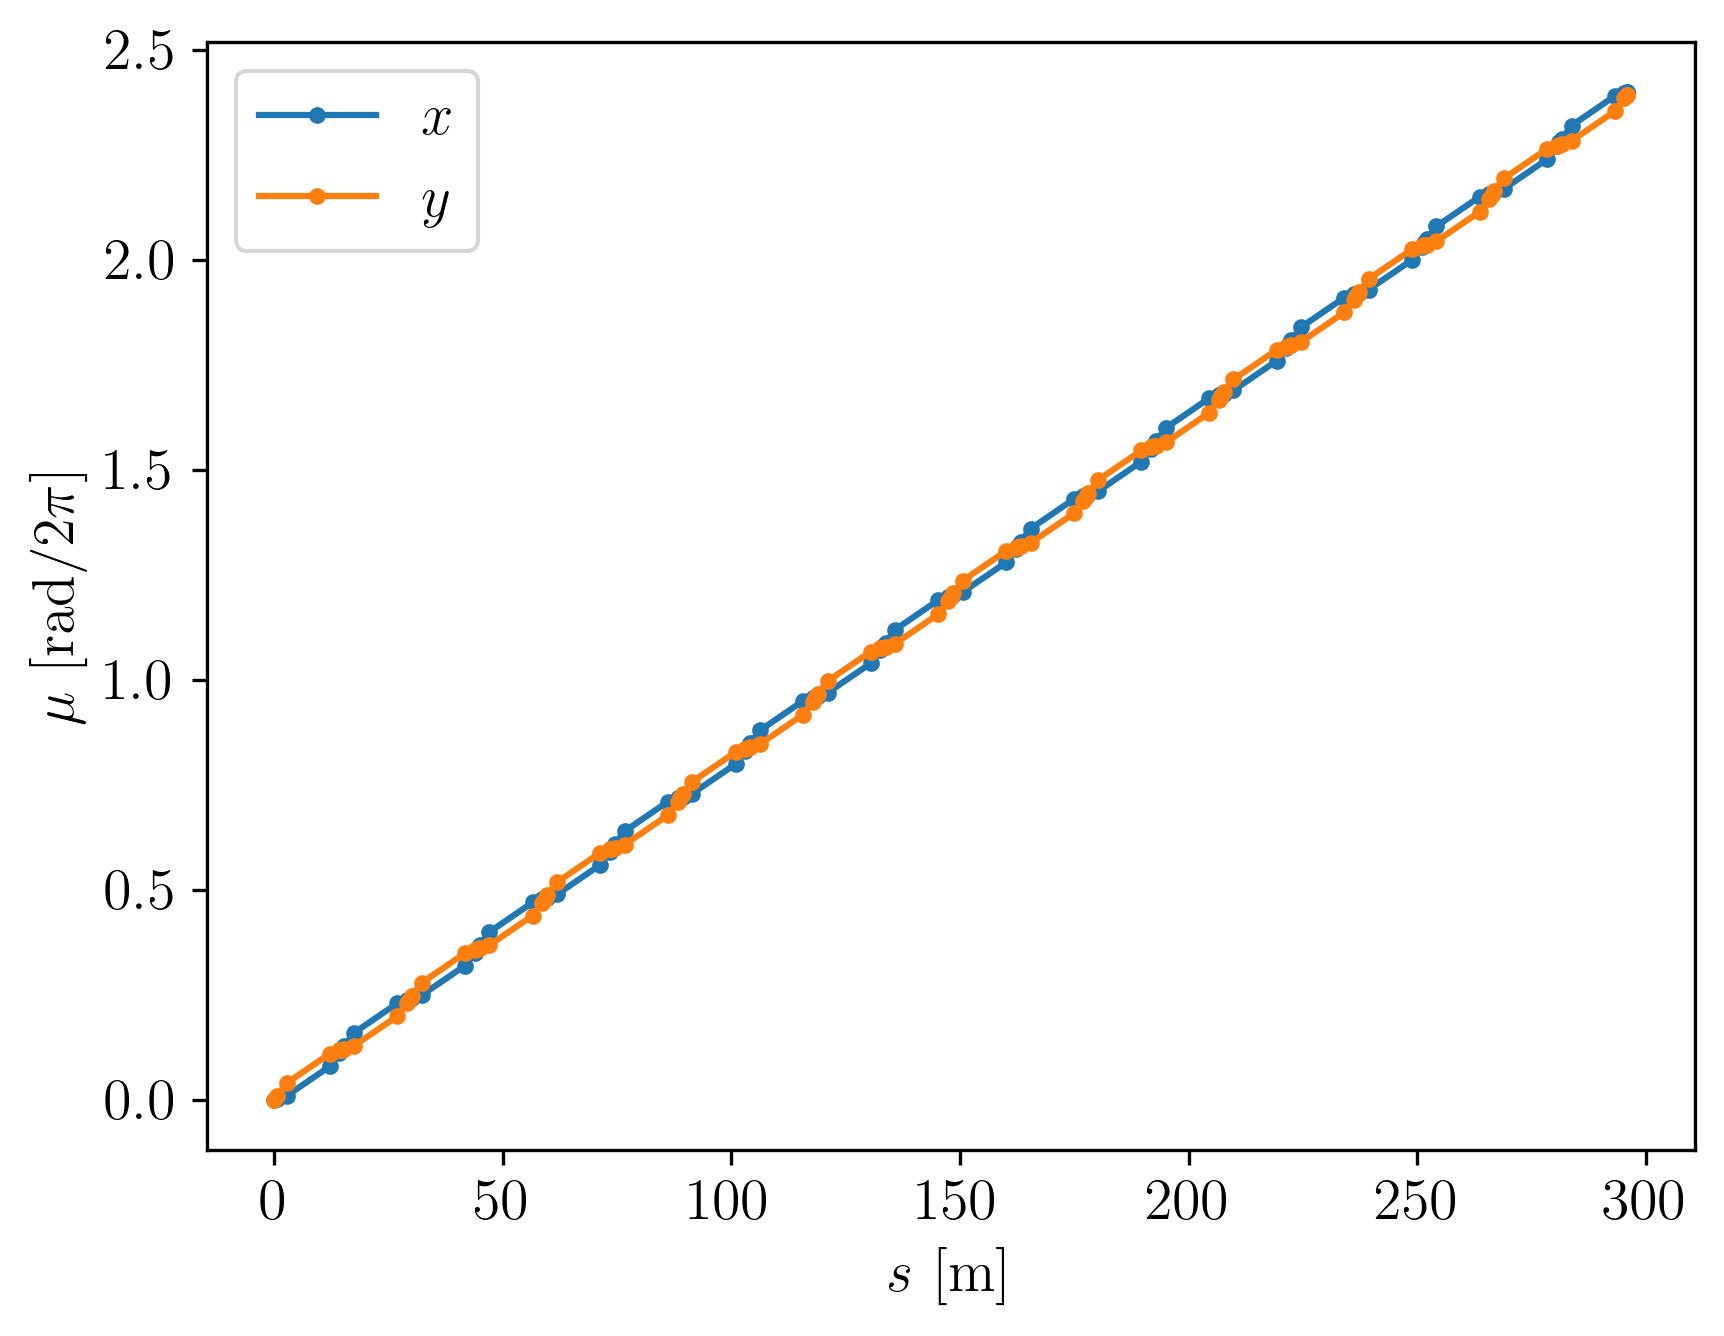

In [59]:
plt.plot(twiss.s,twiss.mux,'.-',label='$x$')
plt.plot(twiss.s,twiss.muy,'.-',label='$y$')
plt.ylabel(r'$\mu$ [rad/2$\pi$]')
plt.xlabel('$s$ [m]')
plt.legend()
plt.show()

Per cell:

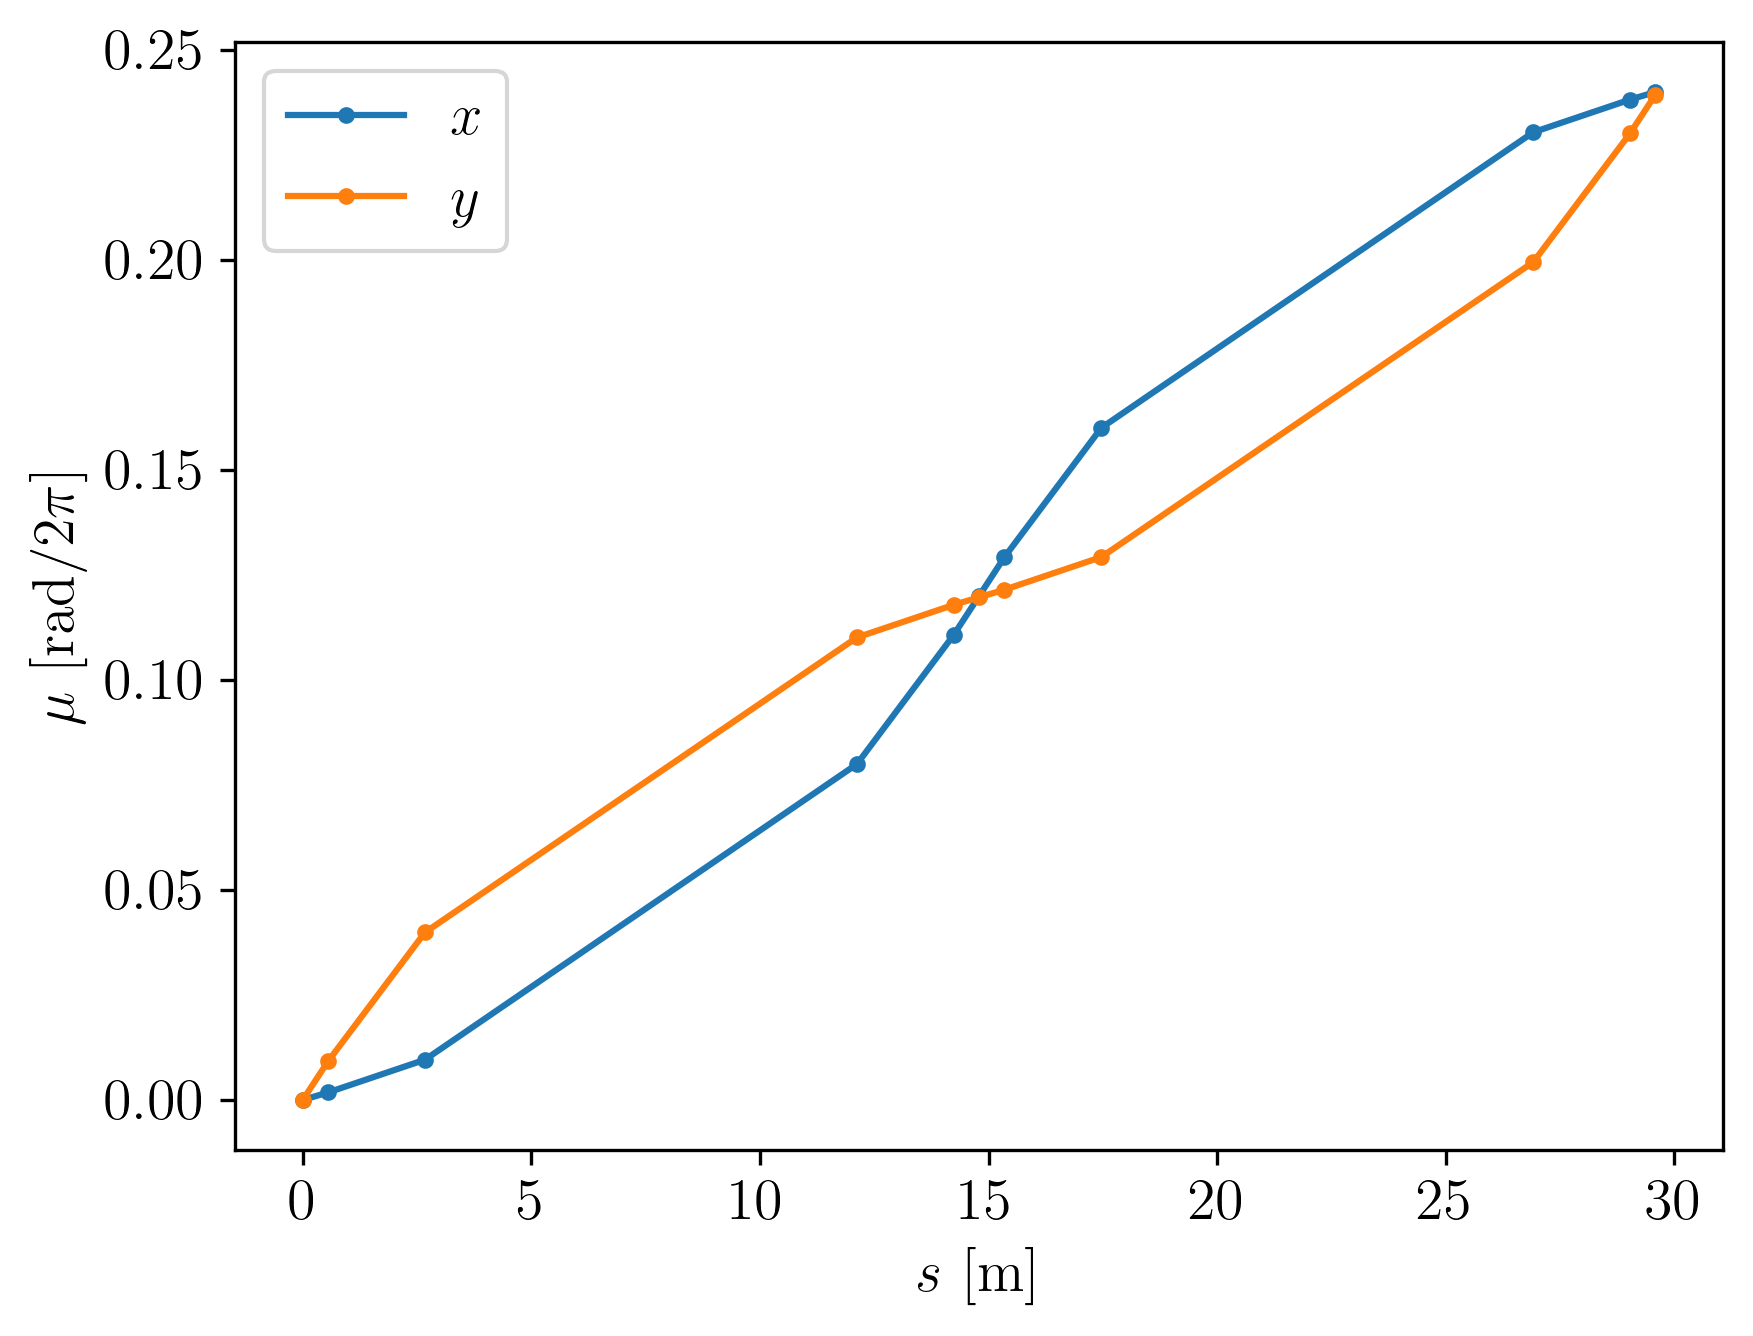

In [60]:
plt.plot(twiss.s[:11],twiss.mux[:11],'.-',label='$x$')
plt.plot(twiss.s[:11],twiss.muy[:11],'.-',label='$y$')
plt.ylabel(r'$\mu$ [rad/2$\pi$]')
plt.xlabel('$s$ [m]')
plt.legend()
plt.show()

In [61]:
twiss.mux[:11]

array([0.        , 0.00180392, 0.00958329, 0.07997641, 0.11073251,
       0.11999475, 0.129257  , 0.1600131 , 0.23040622, 0.23818559,
       0.23998951])

In [62]:
twiss.muy[:11]

array([0.        , 0.00923054, 0.03988672, 0.11012316, 0.11788961,
       0.11969053, 0.12149145, 0.1292579 , 0.19949434, 0.23015053,
       0.23938106])

In [63]:
2*pi*0.12

0.7539822368615503

In [64]:
pi/4

0.7853981633974483

### Observations

- The horizontal and vertical phases are slightly different but with a mirror symmetry along ~y=x.

- The points where the phases are the same happen *around* 0, $\pi/4$, and $\pi/2$.

- Therefore, I believe these points of equivalent horizontal and vertical phases are associated with resonances.

## Case 2 -- one quad error

In [76]:
madx1 = Madx(stdout=False)
madx1.input(f'''
    beam, particle=proton, energy=275.0;
    // Geometry
    L_drift     = 2.116775;
    L_dipole    = 9.45;
    theta       = 0.038924;
    L_half_quad = 0.555;
    
    // Strengths
    kf = 0.08537;
    kd = kf;

    k_error_6 =  0.004;     // error initially OFF !!
    k_error_7 =  0.0;     // error initially OFF  !!
    k_error_test = 0.0;
            
    // Drifts
    D: DRIFT,  L = L_drift;
    
    // Dipoles
    DIP: SBEND, L = L_dipole, ANGLE = theta;
    
    // Quadrupoles -- half length
    QFH1:  QUADRUPOLE, L= L_half_quad, K1=  kf;
    QDH1:  QUADRUPOLE, L= L_half_quad, K1= -kd;
    QFH2:  QUADRUPOLE, L= L_half_quad, K1=  kf;
    QDH2:  QUADRUPOLE, L= L_half_quad, K1= -kd;
    QFH3:  QUADRUPOLE, L= L_half_quad, K1=  kf;
    QDH3:  QUADRUPOLE, L= L_half_quad, K1= -(kd + k_error_test);
    QFH4:  QUADRUPOLE, L= L_half_quad, K1=  kf;
    QDH4:  QUADRUPOLE, L= L_half_quad, K1= -kd;
    QFH5:  QUADRUPOLE, L= L_half_quad, K1=  kf;
    QDH5:  QUADRUPOLE, L= L_half_quad, K1= -kd;
    QFH6:  QUADRUPOLE, L= L_half_quad, K1=  (kf + k_error_6);
    QDH6:  QUADRUPOLE, L= L_half_quad, K1= -kd;
    QFH7:  QUADRUPOLE, L= L_half_quad, K1=  (kf + k_error_7);
    QDH7:  QUADRUPOLE, L= L_half_quad, K1= -kd;
    QFH8:  QUADRUPOLE, L= L_half_quad, K1=  kf;
    QDH8:  QUADRUPOLE, L= L_half_quad, K1= -kd;
    QFH9:  QUADRUPOLE, L= L_half_quad, K1=  kf;
    QDH9:  QUADRUPOLE, L= L_half_quad, K1= -kd;
    QFH10: QUADRUPOLE, L= L_half_quad, K1=  kf;
    QDH10: QUADRUPOLE, L= L_half_quad, K1= -kd;
    
    // Beamlines
    FODODIP: LINE=(D, DIP, D);          // Interior of a half cell
    
    FODO1: LINE=(QFH1,  FODODIP, 2*QDH1,  FODODIP, QFH2);
    FODO2: LINE=(QFH2,  FODODIP, 2*QDH2,  FODODIP, QFH3);
    FODO3: LINE=(QFH3,  FODODIP, 2*QDH3,  FODODIP, QFH4);
    FODO4: LINE=(QFH4,  FODODIP, 2*QDH4,  FODODIP, QFH5);
    FODO5: LINE=(QFH5,  FODODIP, 2*QDH5,  FODODIP, QFH6);
    FODO6: LINE=(QFH6,  FODODIP, 2*QDH6,  FODODIP, QFH7);
    FODO7: LINE=(QFH7,  FODODIP, 2*QDH7,  FODODIP, QFH8);
    FODO8: LINE=(QFH8,  FODODIP, 2*QDH8,  FODODIP, QFH9);
    FODO9: LINE=(QFH9,  FODODIP, 2*QDH9,  FODODIP, QFH10);
    FODO10:LINE=(QFH10, FODODIP, 2*QDH10, FODODIP, QFH1);
    
    FODO_MANY: LINE=(FODO1, FODO2, FODO3, FODO4, FODO5, FODO6, FODO7, FODO8, FODO9, FODO10);
    
    use, sequence=fodo_many;
    // select,                     flag=twiss,column=name,s,betx,bety,alfx,alfy,dx,mux,muy; // see all magnets
       select, class = quadrupole, flag=twiss,column=name,s,betx,bety,alfx,alfy,dx,mux,muy; // see quads only
    set, format="-22s", "11.6f";
    
    twiss, save, file=quad_err.twi;
    ''')
twiss1 = madx1.table.twiss

I am using a value of 0.004 for the k6 error.

### Tune shift

In [96]:
# initial:
q2, q1 = madx.table.summ.q1[0], madx.table.summ.q2[0]

# final:
q21, q11 = madx1.table.summ.q1[0], madx1.table.summ.q2[0]

# shift:
print('Vertical tune shift:')
print(q21 - q2)
print('Horizontal tune shift:')
print(q11 - q1)

Vertical tune shift:
0.018867055345333394
Horizontal tune shift:
-0.003340125627306012


The q2 shift is much larger in magnitude than the q1 shift because the error was applied to kf. To prove this, I applied an error to kd instead and saw the other tune become larger as predicted.

Equation 8.29:
$$ \Delta Q = \tilde{Q} - Q = \frac{\beta_0 \Delta q}{4\pi} $$
where $\beta_0$ is the unperturbed $\beta$-function at the quadrupole error.

In [100]:
dq = 0.004
id_6 = np.where(np.char.find(twiss1.name, "qfh6") >= 0)[0][0]
beta0x = twiss.betx[id_6]
dQx = beta0x*dq/(4*pi)
print('Magnitude of expected horizontal tune shift:')
print(dQx)
beta0y = twiss.bety[id_6]
dQy = beta0y*dq/(4*pi)
print('Magnitude of expected vertical tune shift:')
print(dQy)

Magnitude of expected horizontal tune shift:
0.015723782890674193
Magnitude of expected vertical tune shift:
0.0030162370026030768


The observed and predicted tune shift values agree quite well!

### Beta functions

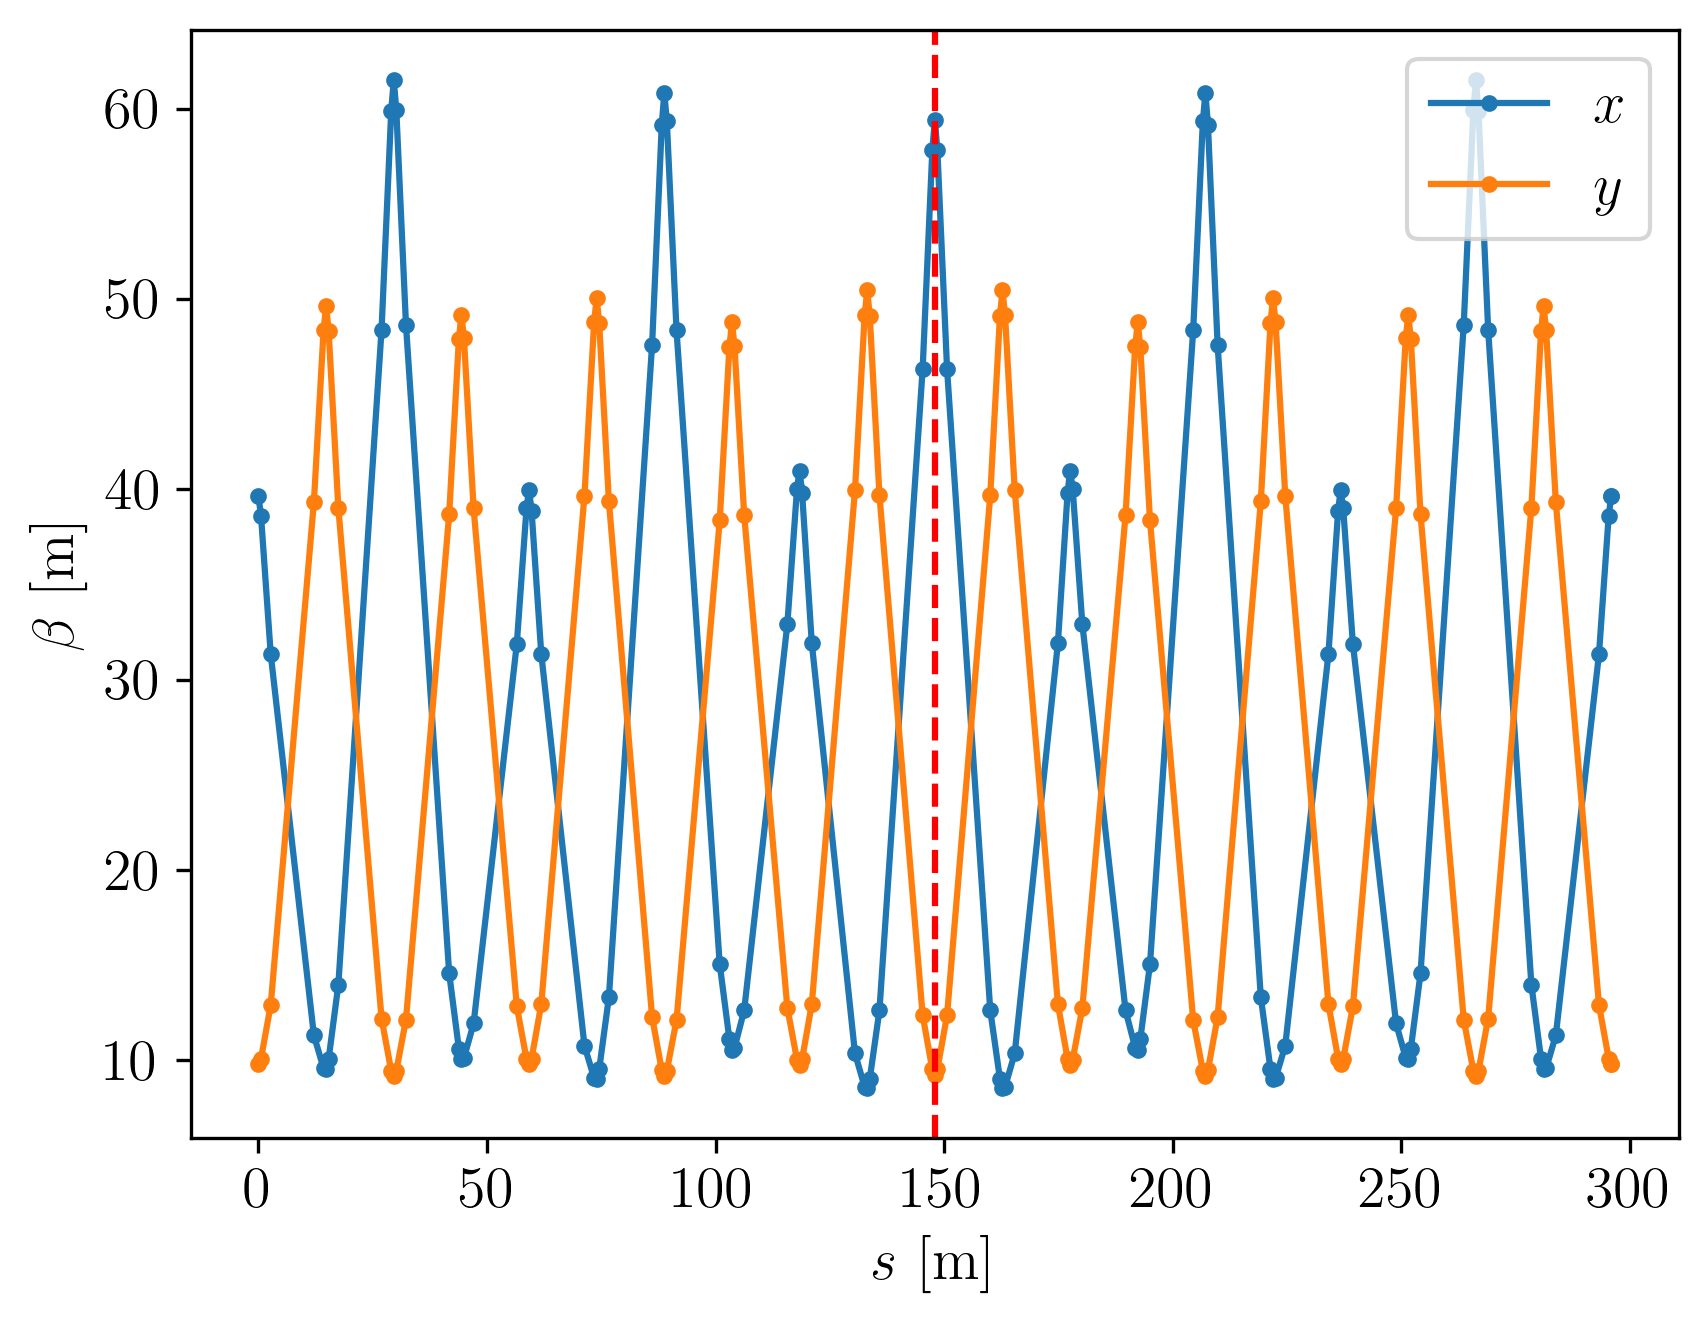

In [101]:
plt.plot(twiss1.s,twiss1.betx,'.-',label='$x$')
plt.plot(twiss1.s,twiss1.bety,'.-',label='$y$')
plt.axvline(twiss1.s[id_6],color='r',linestyle='--')
plt.ylabel(r'$\beta$ [m]')
plt.xlabel('$s$ [m]')
plt.legend()
plt.show()

In [123]:
dbeta_betax = np.abs(twiss1.betx[id_6] - twiss.betx[id_6]) / twiss1.betx[id_6]
print(dbeta_betax)
dbeta_betay = np.abs(twiss1.bety[id_6] - twiss.bety[id_6]) / twiss1.bety[id_6]
print(dbeta_betay)

0.16854884763677844
0.025082484040344948


Equation 8.38:

$$ \frac{\Delta \beta}{\beta} = \frac{-q\beta_0}{2\sin{(2\pi Q)}} \cos(2|\psi-\psi_0|-2\pi Q)

In [121]:
psi_0 = twiss.mux[id_6]
psi = twiss1.mux[id_6]
c = np.cos(2*abs(psi-psi_0)-2*pi*q1)
s = np.sin(2*pi*q1)
beta0 = twiss.betx[id_6]
dbeta_betax_ana = -dq*beta0/(2*s)*c
print(dbeta_betax_ana)

0.12353344588587427


In [122]:
c = np.cos(2*abs(psi-psi_0)-2*pi*q2)
s = np.sin(2*pi*q2)
beta0 = twiss.bety[id_6]
dbeta_betay_ana = -dq*beta0/(2*s)*c
print(dbeta_betay_ana)

0.02568630484674061


The expected values are reasonably close to the observed!

## Case 3 -- two quad errors

In [124]:
madx2 = Madx(stdout=False)
madx2.input(f'''
    beam, particle=proton, energy=275.0;
    // Geometry
    L_drift     = 2.116775;
    L_dipole    = 9.45;
    theta       = 0.038924;
    L_half_quad = 0.555;
    
    // Strengths
    kf = 0.08537;
    kd = kf;

    k_error_6 =  0.004;     // error initially OFF !!
    k_error_7 =  0.004;     // error initially OFF  !!
            
    // Drifts
    D: DRIFT,  L = L_drift;
    
    // Dipoles
    DIP: SBEND, L = L_dipole, ANGLE = theta;
    
    // Quadrupoles -- half length
    QFH1:  QUADRUPOLE, L= L_half_quad, K1=  kf;
    QDH1:  QUADRUPOLE, L= L_half_quad, K1= -kd;
    QFH2:  QUADRUPOLE, L= L_half_quad, K1=  kf;
    QDH2:  QUADRUPOLE, L= L_half_quad, K1= -kd;
    QFH3:  QUADRUPOLE, L= L_half_quad, K1=  kf;
    QDH3:  QUADRUPOLE, L= L_half_quad, K1= -kd;
    QFH4:  QUADRUPOLE, L= L_half_quad, K1=  kf;
    QDH4:  QUADRUPOLE, L= L_half_quad, K1= -kd;
    QFH5:  QUADRUPOLE, L= L_half_quad, K1=  kf;
    QDH5:  QUADRUPOLE, L= L_half_quad, K1= -kd;
    QFH6:  QUADRUPOLE, L= L_half_quad, K1=  (kf + k_error_6);
    QDH6:  QUADRUPOLE, L= L_half_quad, K1= -kd;
    QFH7:  QUADRUPOLE, L= L_half_quad, K1=  (kf + k_error_7);
    QDH7:  QUADRUPOLE, L= L_half_quad, K1= -kd;
    QFH8:  QUADRUPOLE, L= L_half_quad, K1=  kf;
    QDH8:  QUADRUPOLE, L= L_half_quad, K1= -kd;
    QFH9:  QUADRUPOLE, L= L_half_quad, K1=  kf;
    QDH9:  QUADRUPOLE, L= L_half_quad, K1= -kd;
    QFH10: QUADRUPOLE, L= L_half_quad, K1=  kf;
    QDH10: QUADRUPOLE, L= L_half_quad, K1= -kd;
    
    // Beamlines
    FODODIP: LINE=(D, DIP, D);          // Interior of a half cell
    
    FODO1: LINE=(QFH1,  FODODIP, 2*QDH1,  FODODIP, QFH2);
    FODO2: LINE=(QFH2,  FODODIP, 2*QDH2,  FODODIP, QFH3);
    FODO3: LINE=(QFH3,  FODODIP, 2*QDH3,  FODODIP, QFH4);
    FODO4: LINE=(QFH4,  FODODIP, 2*QDH4,  FODODIP, QFH5);
    FODO5: LINE=(QFH5,  FODODIP, 2*QDH5,  FODODIP, QFH6);
    FODO6: LINE=(QFH6,  FODODIP, 2*QDH6,  FODODIP, QFH7);
    FODO7: LINE=(QFH7,  FODODIP, 2*QDH7,  FODODIP, QFH8);
    FODO8: LINE=(QFH8,  FODODIP, 2*QDH8,  FODODIP, QFH9);
    FODO9: LINE=(QFH9,  FODODIP, 2*QDH9,  FODODIP, QFH10);
    FODO10:LINE=(QFH10, FODODIP, 2*QDH10, FODODIP, QFH1);
    
    FODO_MANY: LINE=(FODO1, FODO2, FODO3, FODO4, FODO5, FODO6, FODO7, FODO8, FODO9, FODO10);
    
    use, sequence=fodo_many;
    // select,                     flag=twiss,column=name,s,betx,bety,alfx,alfy,dx,mux,muy; // see all magnets
       select, class = quadrupole, flag=twiss,column=name,s,betx,bety,alfx,alfy,dx,mux,muy; // see quads only
    set, format="-22s", "11.6f";
    
    twiss, save, file=quad_err.twi;
    ''')
twiss2 = madx2.table.twiss

### Beta functions

In [125]:
id_7 = np.where(np.char.find(twiss2.name, "qfh7") >= 0)[0][0]

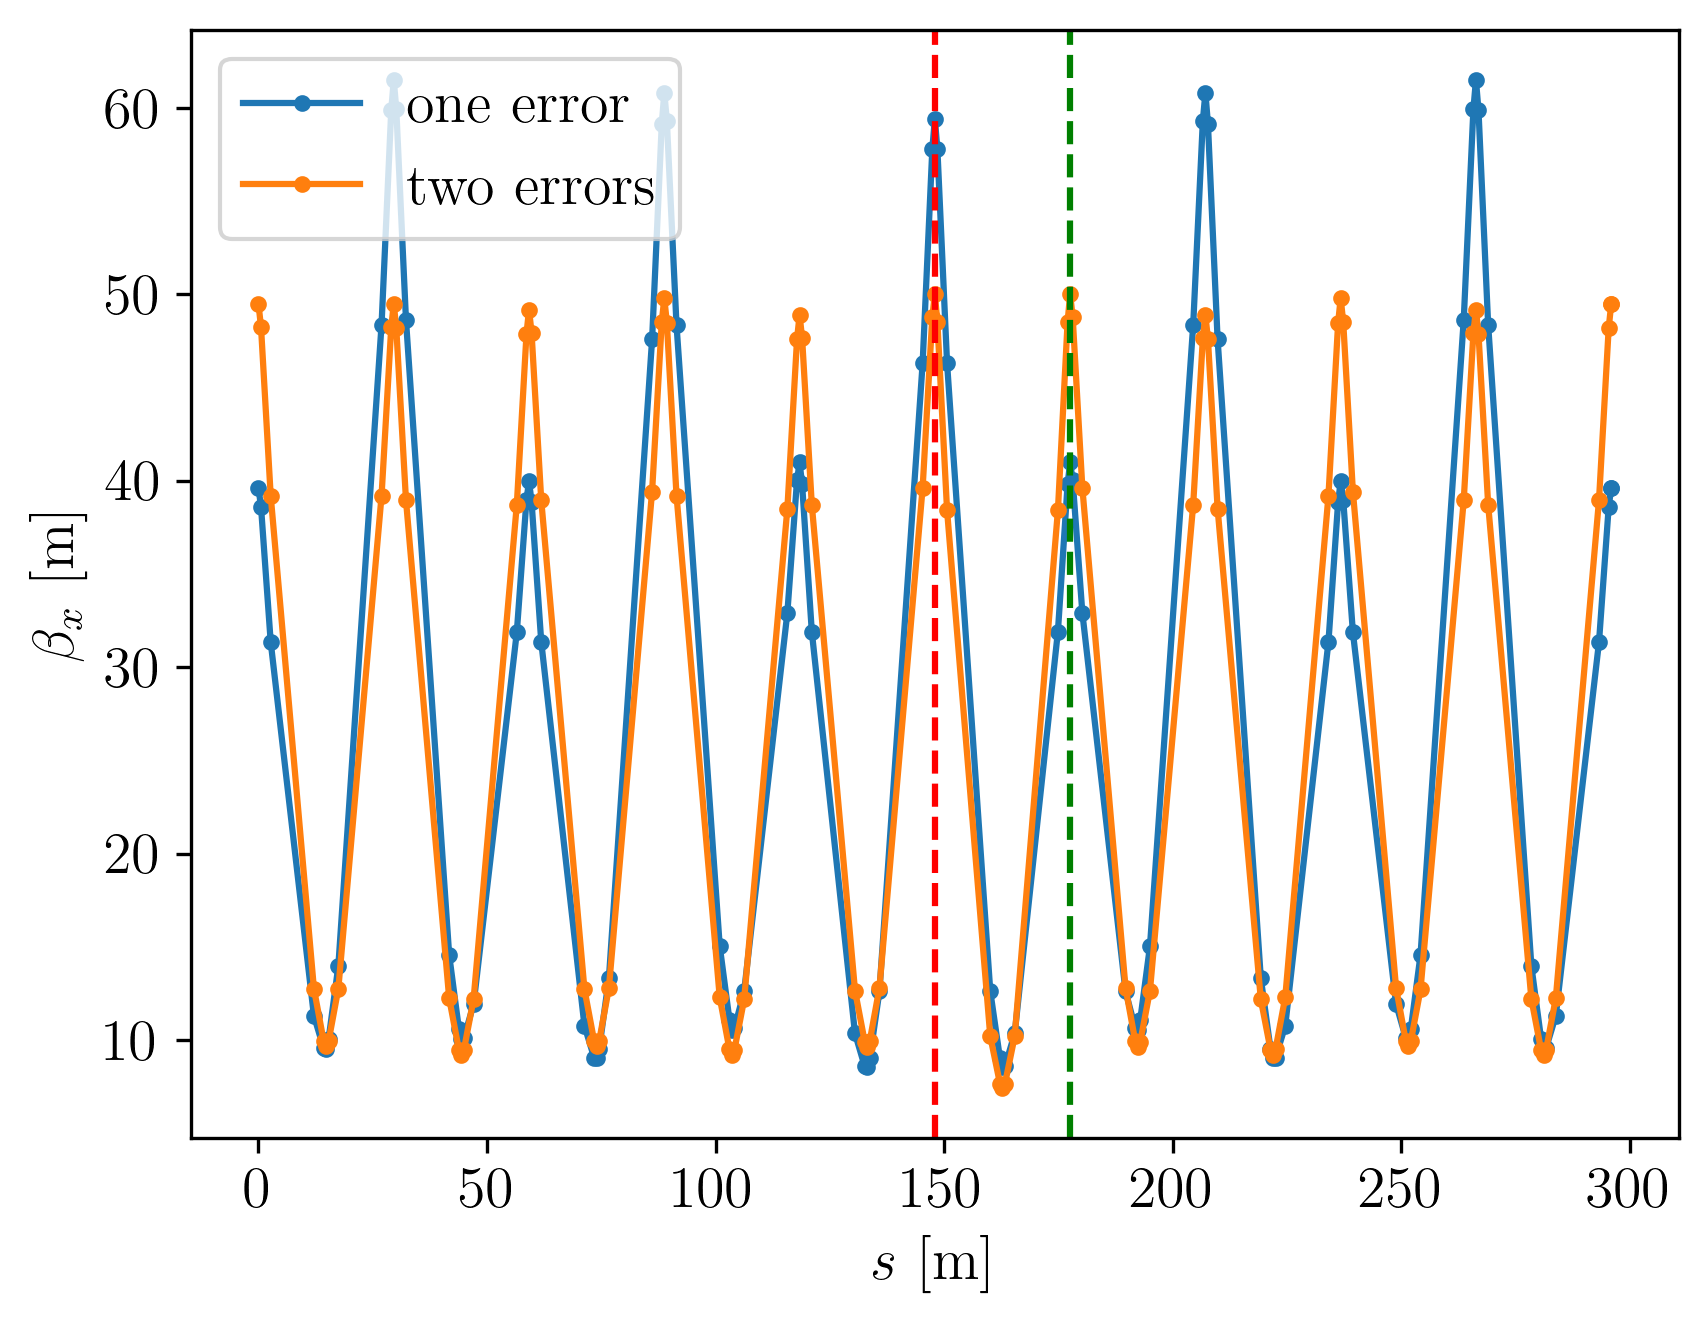

In [127]:
plt.plot(twiss1.s,twiss1.betx,'.-',label='one error')
plt.plot(twiss2.s,twiss2.betx,'.-',label='two errors')
plt.axvline(twiss1.s[id_6],color='r',linestyle='--')
plt.axvline(twiss2.s[id_7],color='g',linestyle='--')
plt.ylabel(r'$\beta_x$ [m]')
plt.xlabel('$s$ [m]')
plt.legend(loc='upper left')
plt.show()

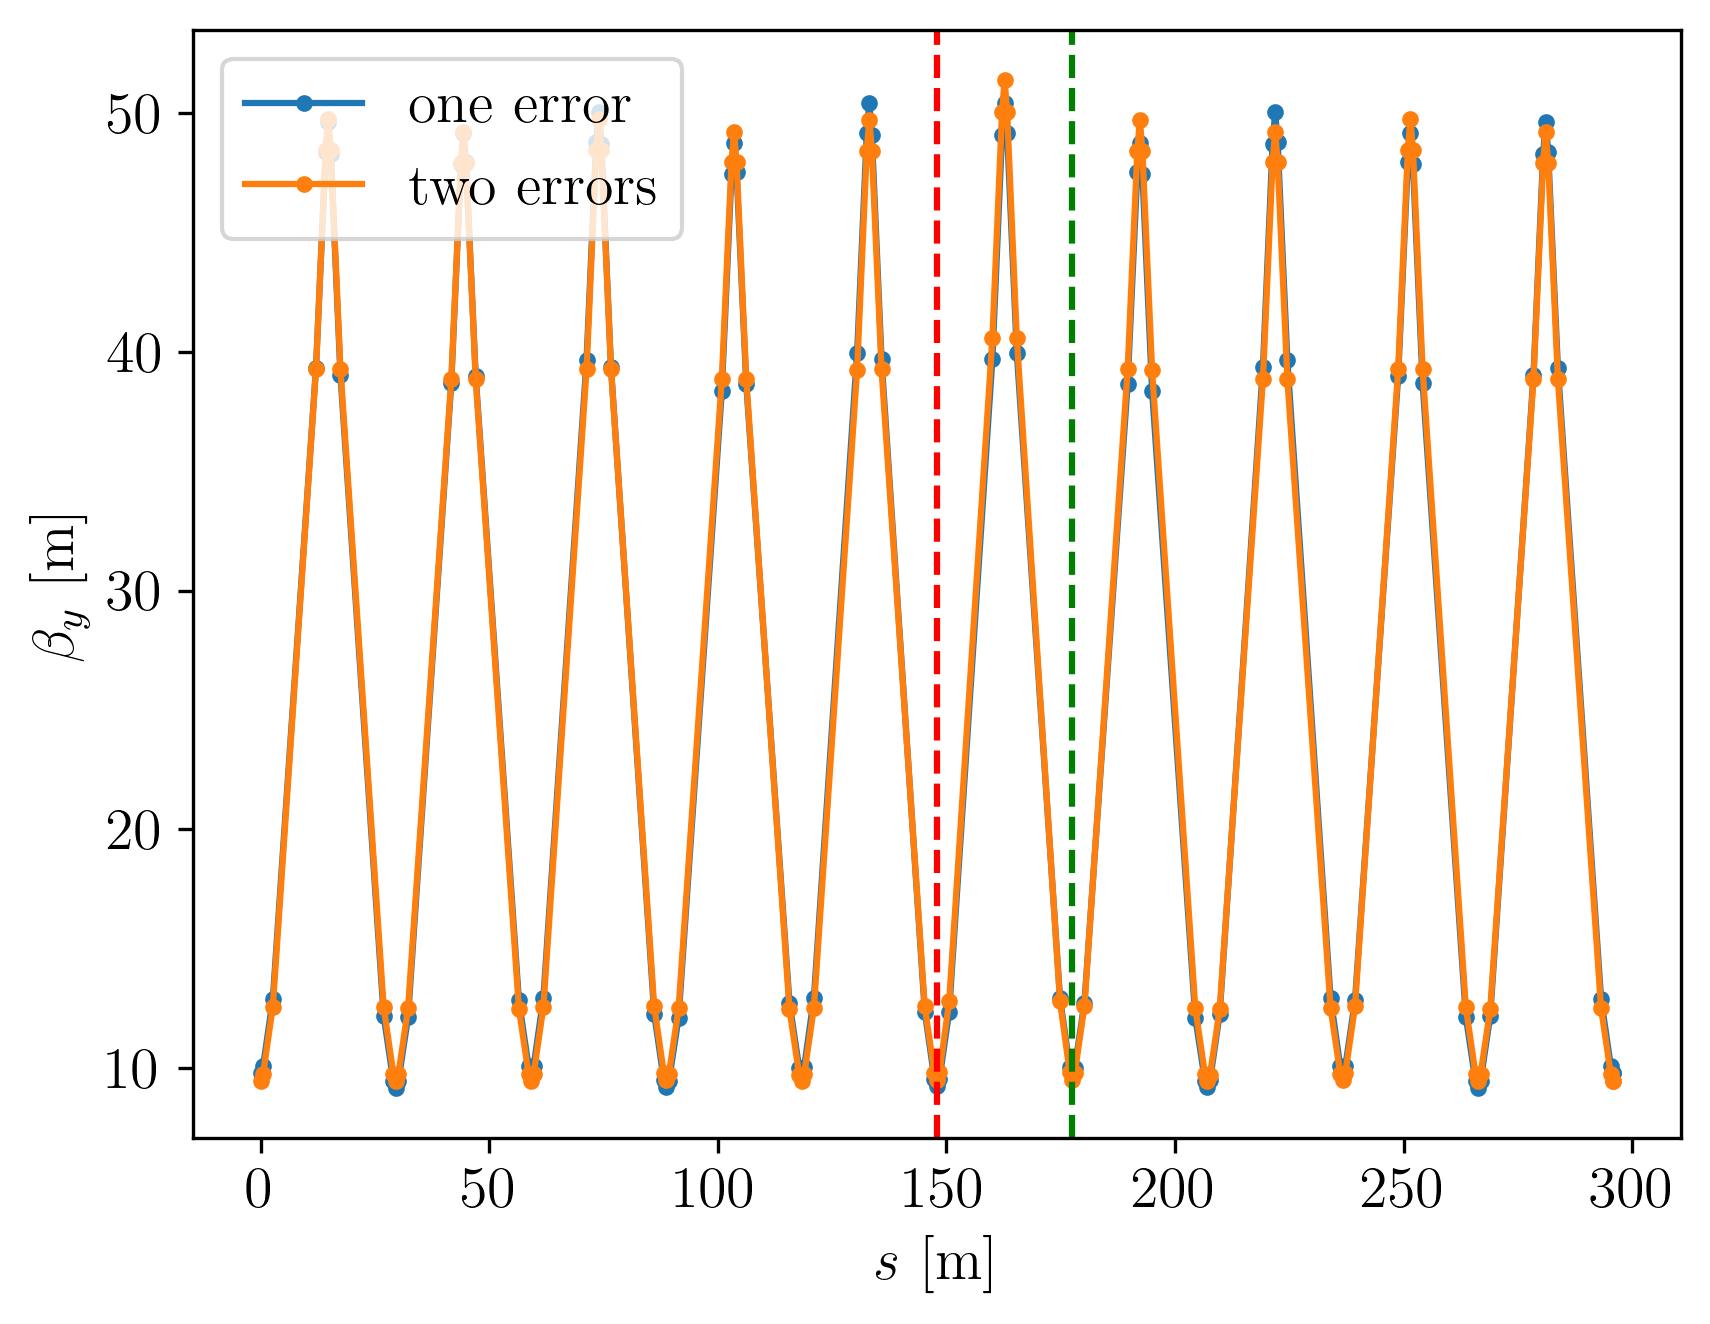

In [128]:
plt.plot(twiss1.s,twiss1.bety,'.-',label='one error')
plt.plot(twiss2.s,twiss2.bety,'.-',label='two errors')
plt.axvline(twiss1.s[id_6],color='r',linestyle='--')
plt.axvline(twiss2.s[id_7],color='g',linestyle='--')
plt.ylabel(r'$\beta_y$ [m]')
plt.xlabel('$s$ [m]')
plt.legend(loc='upper left')
plt.show()

### Observations

- For $\beta_x$, we see the minima of the beta function generally aligned across the one- and two-error cases, while the maxima differ quite significantly. At QFH6, the one-error beta function has a large maximum, and at QFH7 the opposite is true. Continuing outside the range between these quadrupoles, we see the largest maximum oscillating like this through the rest of the lattice.

- Adding a quadrupole error shifted the phase advance per cell, so the extrema of the beta functions were no longer aligned. At some points (minima of beta), there is effectively constructive interference, and the differences cancel out s.t. the two cases look the same. At other points (maxima of beta), the difference is constructively enhanced, and we see the most significant differences across the two cases.

- For $\beta_y$, we see different behavior; the one- and two-error beta functions look nearly identical. This is because we applied an error to a quadrupoles that affect the horizontal direction, so the vertical beta functions were unperturbed.